<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Consideraciones de la Regresión Lineal Múltiple: Sobreajuste y Multicolinealidad ⚖️
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Programación para Ciencia de Datos
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 07
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

---
### 1. Desafíos Clave en la Regresión Lineal Múltiple 🎯

Cuando expandimos un modelo de regresión lineal para incorporar múltiples variables predictoras ($x_1, x_2, \dots, x_n$), surgen tres fenómenos fundamentales que todo científico de datos debe dominar:

```
┌────────────────────────────────────────────────────────────────────────┐
│             Desafíos Críticos en Regresión Lineal Múltiple             │
└───────────────────────────────────┬────────────────────────────────────┘
                                    │
    ┌───────────────────────────────┼───────────────────────────────┐
    ▼                               ▼                               ▼
┌────────────────────────┐      ┌────────────────────────┐      ┌────────────────────────┐
│      Sobreajuste       │      │   Multicolinealidad    │      │ Selección de Variables │
│     (Overfitting)      │      │  (Multicollinearity)   │      │   (Feature Selection)  │
│ • Memorización de ruido│      │ • Variables correlac.  │      │ • Filtrar redundancias │
│ • Falla en datos test  │      │ • Inestabilidad en β   │      │ • Modelo parsimonioso  │
└────────────────────────┘      └────────────────────────┘      └────────────────────────┘
```

1. **Sobreajuste (*Overfitting*):** A medida que se añaden más variables, el modelo gana grados de libertad y tiende a memorizar las observaciones y el ruido del conjunto de entrenamiento, perdiendo capacidad de generalización sobre datos nuevos.
2. **Multicolinealidad (*Multicollinearity*):** Ocurre cuando dos o más variables independientes están moderada o fuertemente interrelacionadas, inflando la varianza de los coeficientes estimados y dificultando la inferencia causal.
3. **Selección de Características (*Feature Selection*):** Identificar el conjunto óptimo y parsimonioso de predictores, descartando variables ruidosas o redundantes.

---
### 2. El Dilema Sesgo-Varianza (*Bias-Variance Tradeoff*) 🎢

Para comprender el sobreajuste y el subajuste, es indispensable analizar los conceptos de **Sesgo** y **Varianza**:

* **Sesgo (*Bias*):** Cuantifica el error sistemático introducido por aproximar un problema del mundo real mediante un modelo demasiado simple o restrictivo. Los modelos lineales suelen tener alto sesgo pero son rápidos y estables.
* **Varianza (*Variance*):** Mide la sensibilidad del modelo ante variaciones en el conjunto de entrenamiento. Un modelo con alta varianza cambia drásticamente ante pequeñas modificaciones en los datos observados.

<div align="center">
  <img src="images/Tree2.gif" width="560" alt="Bias-Variance Tradeoff" style="border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); margin: 15px 0;"/>
  <p style="font-size: 0.85em; color: #64748b;">
    <i>Figura: El compromiso entre Sesgo y Varianza. A mayor complejidad del modelo, el sesgo disminuye pero la varianza se incrementa exponencialmente (<a href="https://cs109.org/">Harvard CS109</a>).</i>
  </p>
</div>

#### Descomposición Matemática del Error Cuadrático Esperado:
Para cualquier modelo predictivo $\hat{f}(\mathbf{x})$, el error esperado de predicción sobre una muestra no observada $\mathbf{x}_0$ se descompone formalmente en:

$$\mathbb{E}\left[\left(y_0 - \hat{f}(\mathbf{x}_0)\right)^2\right] = \underbrace{\left(\text{Bias}\left[\hat{f}(\mathbf{x}_0)\right]\right)^2}_{\text{Sesgo al cuadrado}} + \underbrace{\text{Var}\left(\hat{f}(\mathbf{x}_0)\right)}_{\text{Varianza del modelo}} + \underbrace{\sigma_\varepsilon^2}_{\text{Error irreducible}}$$

> 📌 **El Principio del Trade-off:**  
> Existe una relación inversa ineludible: reducir el sesgo suele aumentar la varianza, y viceversa. El objetivo en Machine Learning es encontrar el punto de equilibrio óptimo que minimice el error total de prueba.

---
### 3. Diagnóstico y Estrategias de Mitigación 🛡️

| Condición | Diagnóstico de Rendimiento | Causa Raíz | Estrategias de Solución |
|---|:---:|---|---|
| **Sobreajuste (*Overfitting*)** | $R^2_{\text{train}}$ muy alto<br>$R^2_{\text{test}}$ bajo | • Bajo sesgo, alta varianza<br>• Demasiadas variables o complejidad<br>• Memorización de ruido aleatorio | 1. Recolectar más datos limpios.<br>2. Selección de características (*Feature Selection*).<br>3. Regularización ($L_1$ Lasso, $L_2$ Ridge).<br>4. Validación cruzada (*Cross-Validation*). |
| **Subajuste (*Underfitting*)** | $R^2_{\text{train}}$ bajo<br>$R^2_{\text{test}}$ bajo | • Alto sesgo, baja varianza<br>• Modelo demasiado rígido<br>• Incapacidad de capturar la tendencia | 1. Aumentar la complejidad del modelo.<br>2. Crear nuevas características e interacciones ($x_1 \cdot x_2$).<br>3. Regresión Polinomial ($x^2, x^3$).<br>4. Probar modelos no lineales (k-NN, árboles). |

---
### 4. Multicolinealidad: Causas, Efectos y Diagnóstico 🔍

La **Multicolinealidad** se produce cuando dos o más variables predictoras independientes en un modelo de regresión múltiple están fuertemente correlacionadas entre sí.

#### ¿Por qué es un problema crítico?
* **Inestabilidad de los Coeficientes ($\hat{\beta}_j$):** Pequeños cambios en los datos de entrenamiento pueden provocar que los coeficientes oscilen drásticamente o incluso cambien de signo.
* **Invalidez de la Inferencia Estadística:** Dificulta determinar qué variable contribuye realmente a la predicción del target y cuál es su impacto individual, inflando los errores estándar y arruinando la interpretación de los $p$-valores.
* **Impacto en Predicción vs Inferencia:**  
  *La multicolinealidad NO reduce la precisión predictiva global del modelo ($\hat{y}$ se mantiene estable), pero destruye la interpretabilidad y la inferencia causal.*

---
### 5. Detección de Multicolinealidad: Matriz de Correlación y VIF 📊

#### 5.1 Matriz de Correlaciones Bivariadas:
Permite una primera inspección visual mediante coeficientes de Pearson $r \in [-1, 1]$. Sin embargo, no detecta colinealidad cuando una variable es combinación lineal de otras tres o más variables.

#### 5.2 Factor de Inflación de la Varianza (*Variance Inflation Factor - VIF*):
Para evaluar la multicolinealidad multivariada, se ajusta una regresión lineal auxiliar para cada variable $X_j$ usando a todas las demás $(p-1)$ variables predictoras como regresores:

$$X_j = \alpha_0 + \sum_{k \neq j} \alpha_k X_k + \varepsilon_j$$

A partir del coeficiente de determinación $R_j^2$ de dicha regresión auxiliar, el **VIF** se calcula como:

$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$

```
                          ┌───────────────────────────────┐
                          │   Interpretación del VIF      │
                          └───────────────┬───────────────┘
                                          │
        ┌─────────────────────────────────┼─────────────────────────────────┐
        ▼                                 ▼                                 ▼
┌────────────────────────┐      ┌────────────────────────┐      ┌────────────────────────┐
│      VIF = 1.0         │      │     1.0 < VIF < 5.0    │      │       VIF ≥ 5.0        │
│ • Ausencia total de    │      │ • Correlación moderada │      │ • Multicolinealidad    │
│   multicolinealidad    │      │ • Rango seguro para    │      │   problemática         │
│ • Variables ortogonales│      │   inferencia           │      │ • Requiere corrección  │
└────────────────────────┘      └────────────────────────┘      └────────────────────────┘
```

In [1]:
try:
    from IPython.core.interactiveshell import InteractiveShell
    InteractiveShell.ast_node_interactivity = 'all'
except Exception:
    pass
try:
    from IPython.display import display
except Exception:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado y métricas de regresión
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Cálculo de VIF para diagnóstico de multicolinealidad
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["font.size"] = 10

np.random.seed(0)
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', 6)

print("✅ Entorno preparado para el análisis de Sobreajuste y Multicolinealidad.")

✅ Entorno preparado para el análisis de Sobreajuste y Multicolinealidad.


In [2]:
# Carga y preparación del conjunto de datos Advertising
adv_data = pd.read_csv("data/Advertising.csv")
if 'Unnamed: 0' in adv_data.columns:
    adv_data = adv_data[['TV', 'Radio', 'Newspaper', 'Sales']]

X_features = ['TV', 'Radio', 'Newspaper']
display(adv_data.head())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9


---
### 6. Diagnóstico de Multicolinealidad en el Dataset Advertising 📊

Inspeccionemos la matriz de correlación de los predictores (`TV`, `Radio`, `Newspaper`).

🔍 Se observa una correlación moderada entre Radio y Newspaper (r ≈ 0.354).


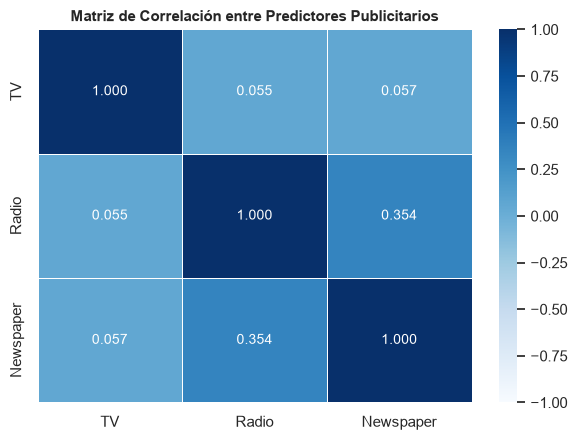

In [3]:
# 1. Matriz de correlación bivariada entre los predictores
plt.figure(figsize=(6, 4.5), dpi=100)
sns.heatmap(adv_data[X_features].corr(), annot=True, cmap='Blues', fmt='.3f', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación entre Predictores Publicitarios', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("🔍 Se observa una correlación moderada entre Radio y Newspaper (r ≈ 0.354).")

In [4]:
# 2. Cálculo del Factor de Inflación de la Varianza (VIF) para cada variable
X_mat = adv_data[X_features].to_numpy()

vif_data = pd.DataFrame({
    'Variable': X_features,
    'VIF': [variance_inflation_factor(X_mat, i) for i in range(X_mat.shape[1])]
})

display(vif_data)

print("\n🔍 Interpretación de VIF:")
for _, row in vif_data.iterrows():
    estado = "Aceptable (< 5)" if row['VIF'] < 5 else "⚠️ Problemático (≥ 5)"
    print(f" - {row['Variable']:12s}: VIF = {row['VIF']:.4f} ──► {estado}")

    Variable       VIF
0         TV  2.486772
1      Radio  3.285462
2  Newspaper  3.055245

🔍 Interpretación de VIF:
 - Newspaper   : VIF = 3.0552 ──► Aceptable (< 5)


---
##### 🛠️ Práctica 1: Creación de Colinealidad Sintética y Diagnóstico de VIF

Para observar el impacto directo de la multicolinealidad severa sobre los coeficientes de regresión, simularemos un canal publicitario redundante (`Radio_Digital`) altamente correlacionado con `Radio`.

**Instrucciones:**
1. Crea una copia de `adv_data` y añade la variable: `df['Radio_Digital'] = df['Radio'] * 1.05 + np.random.randn(len(df)) * 0.2`.
2. Calcula y grafica la nueva matriz de correlación incluyendo `['TV', 'Radio', 'Newspaper', 'Radio_Digital']`.
3. Calcula el nuevo **VIF** para las 4 variables. ¿Qué ocurrió con el VIF de `Radio` y `Radio_Digital`?
4. Ajusta un modelo de `LinearRegression()` con las 4 variables y observa cómo los coeficientes de `Radio` y `Radio_Digital` se desestabilizan.
5. Elimina `Radio_Digital` y comprueba cómo el modelo recupera coeficientes estables y confiables.

In [ ]:
# =========================================================================
# TU SOLUCIÓN: Simulación de Multicolinealidad y Diagnóstico con VIF
# =========================================================================

# 1. Generar copia y variable colineal
# df_colineal = adv_data.copy()
# df_colineal['Radio_Digital'] = ...

# 2. Calcular VIF de las 4 variables
# features_4 = ['TV', 'Radio', 'Newspaper', 'Radio_Digital']
# vif_colineal = ...

# 3. Ajustar LinearRegression y observar coeficientes
# mod_col = ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1. Generar variable redundante colineal
df_colineal = adv_data.copy()
np.random.seed(42)
df_colineal['Radio_Digital'] = df_colineal['Radio'] * 1.05 + np.random.randn(len(df_colineal)) * 0.2

# 2. Cálculo de VIF con las 4 variables
features_4 = ['TV', 'Radio', 'Newspaper', 'Radio_Digital']
X_col_mat = df_colineal[features_4].to_numpy()

vif_col_df = pd.DataFrame({
    'Variable': features_4,
    'VIF': [variance_inflation_factor(X_col_mat, i) for i in range(X_col_mat.shape[1])]
})

print("=" * 55)
print("📊 VIF CON MULTICOLINEALIDAD INDUCIDA:")
print("=" * 55)
display(vif_col_df)

# 3. Ajuste del modelo con multicolinealidad
mod_col = LinearRegression(fit_intercept=True)
mod_col.fit(df_colineal[features_4], df_colineal['Sales'])

print("\n⚠️ Coeficientes con Multicolinealidad:")
for col, coef in zip(features_4, mod_col.coef_):
    print(f" - {col:15s}: {coef:+.6f}")

print("\n💡 Conclusión:")
print("El VIF de Radio y Radio_Digital se disparó (> 100). Los coeficientes se vuelven inestables")
print("debido a que ambas variables compiten por explicar la misma varianza compartida.")
```
</details>

---
### 7. Resumen y Recursos Recomendados 📌

1. **Trade-off Sesgo-Varianza:** La complejidad del modelo debe balancearse mediante regularización o validación cruzada para evitar el sobreajuste.
2. **Multicolinealidad:** Se diagnostica formalmente mediante el **VIF** ($\text{VIF} \ge 5$ señala problemas). No afecta severamente la predicción global $\hat{y}$, pero invalida la inferencia y desestabiliza los coeficientes $\hat{\beta}_j$.
3. **Solución a la Multicolinealidad:** Eliminar variables redundantes, aplicar transformaciones o utilizar técnicas de reducción dimensional (PCA) y regularización (Ridge / Lasso).

### 📚 Recursos Adicionales:
* **[Penn State STAT 501: Lesson 12 - Multicollinearity](https://online.stat.psu.edu/stat501/lesson/12)**.
* **[Why Multicollinearity Does Not Affect the Precision of Predictions](https://stats.stackexchange.com/a/361609/253229)** — *Cross Validated / StackExchange*.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Programación para Ciencia de Datos</i>
  </p>
</div>